# Dataset-wise Excel Table Visualization

첨부 표의 점수를 데이터셋별로 시각화합니다.

- 좌측: `FeaturedMoE`
- 중앙: `Traditional models` (`SASRec`, `GRU4Rec`, `SR-GNN`, `Caser`)
- 우측: `Recent models` (`FAME`, `BSARec`, `FENRec`, `SIGMA`, `MSSR`, `Patt`)


In [8]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

featured_model = ['FMoE']
traditional_models = ['SASRec', 'GRU4Rec', 'SR-GNN']
recent_models = ['FAME', 'BSARec', 'FENRec', 'SIGMA', 'Patt']
all_models = featured_model + traditional_models + recent_models

data = {
    'KuaiRec_0.2': {
        'FMoE': 0.0811, 'SASRec': 0.0785, 'GRU4Rec': 0.0775, 'SR-GNN': 0.0694, 
        'FAME': 0.0792, 'BSARec': 0.0789, 'FENRec': 0.0778, 'SIGMA': 0.0800, 'Patt': 0.0790,
    },
    'Last.fm_0.03': {
        'FMoE': 0.4076, 'SASRec': 0.4020, 'GRU4Rec': 0.3797, 'SR-GNN': 0.3988, 
        'FAME': 0.3949, 'BSARec': 0.3978, 'FENRec': 0.4038, 'SIGMA': 0.4032, 'Patt': 0.4009,
    },
}

group_specs = [
    ('FeaturedMoE', featured_model, {'FMoE': '#1f77b4'}),
    ('Traditional Models', traditional_models, {
        'SASRec': '#2ca25f',
        'GRU4Rec': '#41ab5d',
        'SR-GNN': '#66c2a4',
        'Caser': '#238b45',
    }),
    ('Recent Models', recent_models, {
        'FAME': '#f16913',
        'BSARec': '#fd8d3c',
        'FENRec': '#fdae6b',
        'SIGMA': '#e6550d',
        'MSSR': '#fdd0a2',
        'Patt': '#d94801',
    }),
]


def _y_limits(values: list[float]) -> tuple[float, float]:
    v_max = max(values)
    v_min = min(values)
    pad_top = max(0.01, v_max * 0.18)
    y_min = max(0.0, v_min - max(0.005, (v_max - v_min) * 0.15))
    y_max = v_max + pad_top
    if y_max <= y_min:
        y_max = y_min + 0.05
    return y_min, y_max


def plot_dataset(dataset_name: str) -> None:
    row = data[dataset_name]

    x_positions = []
    labels = []
    values = []
    colors = []
    group_ranges = []

    x_cursor = 0.0
    gap = 0.55

    for group_name, models, palette in group_specs:
        available = [(m, row[m]) for m in models if row[m] is not None]
        if not available:
            continue

        start = x_cursor
        for model, value in available:
            x_positions.append(x_cursor)
            labels.append(model)
            values.append(value)
            colors.append(palette.get(model, '#999999'))
            x_cursor += 1.0
        end = x_cursor - 1.0

        group_ranges.append((group_name, start, end))
        x_cursor += gap

    if not values:
        print(f'{dataset_name}: no available values to plot')
        return

    y_min, y_max = _y_limits(values)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4.8), constrained_layout=True)
    bars = ax.bar(
        x_positions,
        values,
        color=colors,
        width=0.78,
        edgecolor='#f5f5f5',
        linewidth=1.1,
        zorder=3,
    )

    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=25)
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    ax.set_ylabel('Score')

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (y_max - y_min) * 0.012,
            f'{value:.4f}',
            ha='center',
            va='bottom',
            fontsize=8,
        )

    for idx, (group_name, start, end) in enumerate(group_ranges):
        center = (start + end) / 2
        ax.text(
            center,
            y_max - (y_max - y_min) * 0.02,
            group_name,
            ha='center',
            va='top',
            fontsize=10,
            fontweight='bold',
            color='#444444',
        )

        if idx < len(group_ranges) - 1:
            next_start = group_ranges[idx + 1][1]
            sep_x = (end + next_start) / 2
            ax.axvline(sep_x, color='#777777', linestyle='--', linewidth=1.2, alpha=0.85)

    ax.set_title(f'{dataset_name} | Model Score Comparison', fontsize=13, fontweight='bold')
    plt.show()


def plot_fmoe_vs_sasrec() -> None:
    datasets = []
    fmoe_scores = []
    sasrec_scores = []

    for ds, row in data.items():
        if row.get('FMoE') is not None and row.get('SASRec') is not None:
            datasets.append(ds)
            fmoe_scores.append(row['FMoE'])
            sasrec_scores.append(row['SASRec'])

    x = np.arange(len(datasets))
    width = 0.36

    y_min, y_max = _y_limits(fmoe_scores + sasrec_scores)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5), constrained_layout=True)
    bars1 = ax.bar(x - width / 2, fmoe_scores, width, label='FMoE', color='#1f77b4', edgecolor='white')
    bars2 = ax.bar(x + width / 2, sasrec_scores, width, label='SASRec', color='#2ca25f', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel('Score')
    ax.set_title('FMoE vs SASRec by Dataset', fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.legend(frameon=False)

    for bars in [bars1, bars2]:
        for b in bars:
            v = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, v + (y_max - y_min) * 0.012, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

    plt.show()


def plot_aggregated_models_excluding_sparse() -> None:
    core_datasets = ['Amazon', 'Movielens', 'Foursquare', 'Retail']
    df_core = pd.DataFrame.from_dict({k: data[k] for k in core_datasets}, orient='index')[all_models]

    raw_mean = df_core.mean(axis=0, skipna=True)
    norm_df = df_core.div(df_core.max(axis=1), axis=0)
    norm_mean = norm_df.mean(axis=0, skipna=True)

    order = raw_mean.sort_values(ascending=False).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    axes[0].bar(order, raw_mean[order], color=['#1f77b4' if m == 'FMoE' else '#4c9f70' if m in traditional_models else '#e67e22' for m in order], edgecolor='white')
    axes[0].set_title('Aggregated Mean Score (Amazon/Movielens/Foursquare/Retail)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Mean score')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', linestyle='--', alpha=0.25)

    axes[1].bar(order, norm_mean[order], color=['#1f77b4' if m == 'FMoE' else '#4c9f70' if m in traditional_models else '#e67e22' for m in order], edgecolor='white')
    axes[1].set_title('Aggregated Mean Relative Score (dataset-max normalized)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean relative score')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].grid(axis='y', linestyle='--', alpha=0.25)

    plt.show()



In [9]:
df = pd.DataFrame.from_dict(data, orient='index')[all_models]
df


,FMoE,SASRec,GRU4Rec,SR-GNN,FAME,BSARec,FENRec,SIGMA,Patt
KuaiRec_0.2,0.0811,0.0785,0.0775,0.0694,0.0792,0.0789,0.0778,0.0800,0.0790
Last.fm_0.03,0.4076,0.4020,0.3797,0.3988,0.3949,0.3978,0.4038,0.4032,0.4009


## Amazon


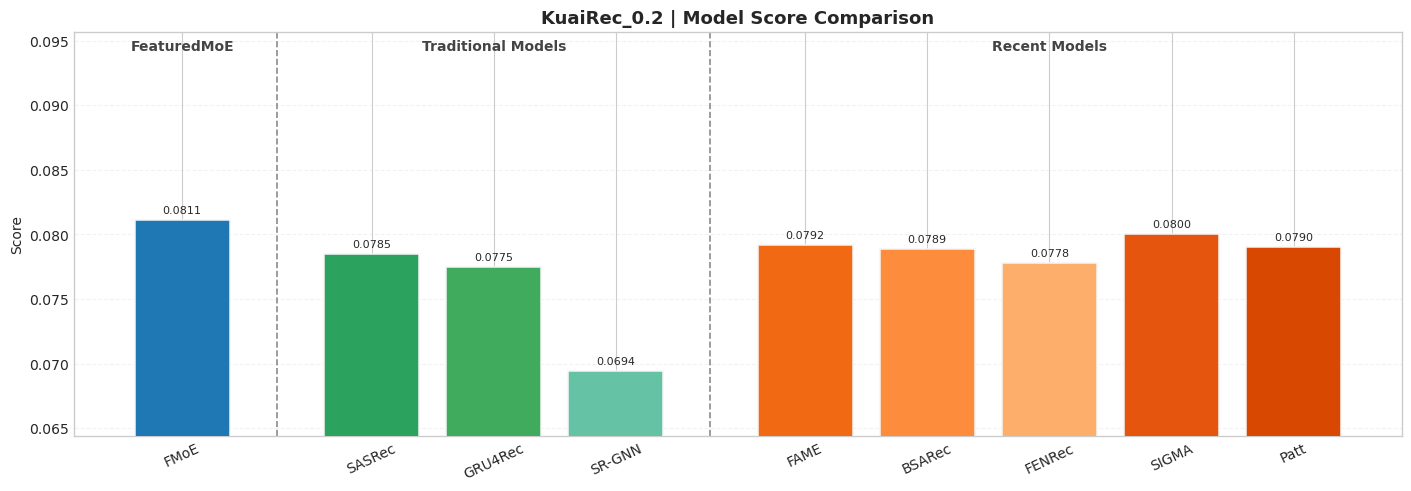

In [10]:
plot_dataset('KuaiRec_0.2')


## Movielens


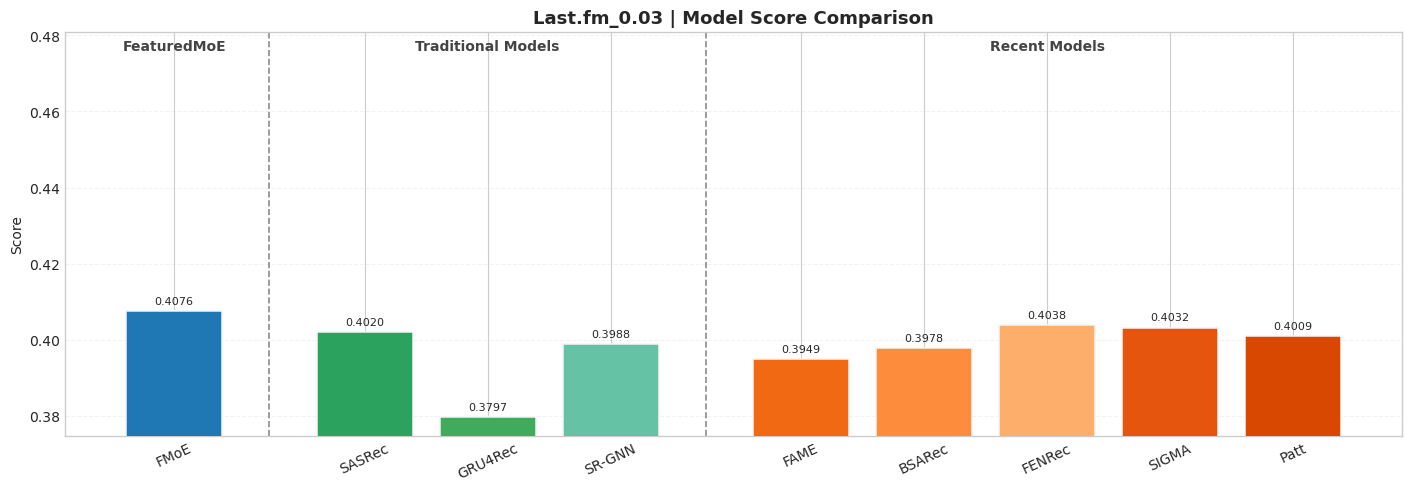

In [11]:
plot_dataset('Last.fm_0.03')


## Foursquare


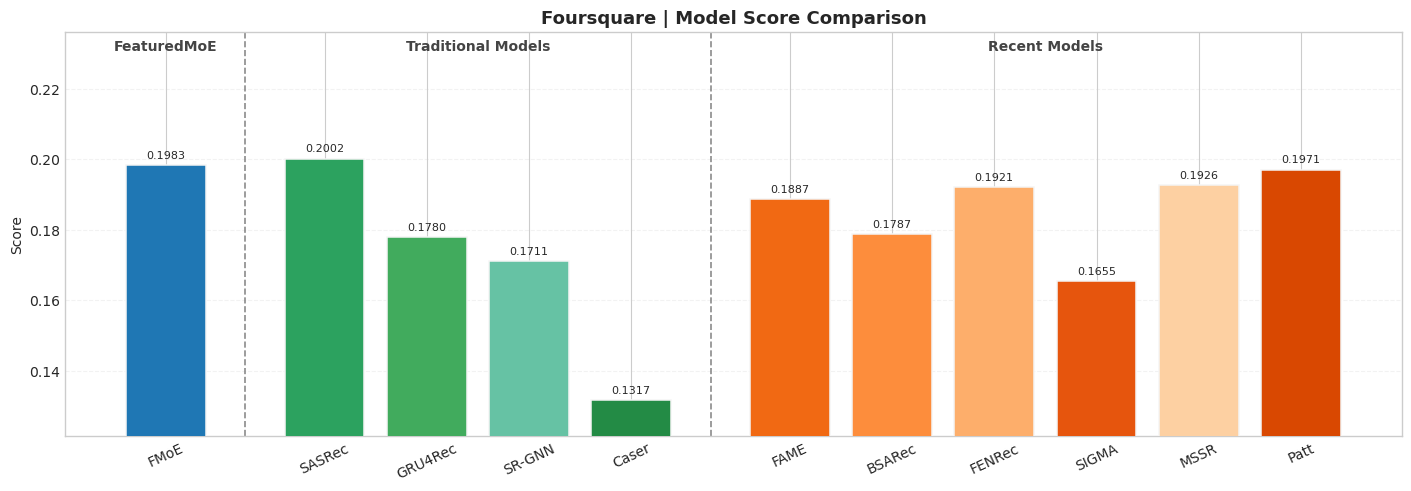

In [5]:
plot_dataset('Foursquare')


## Retail


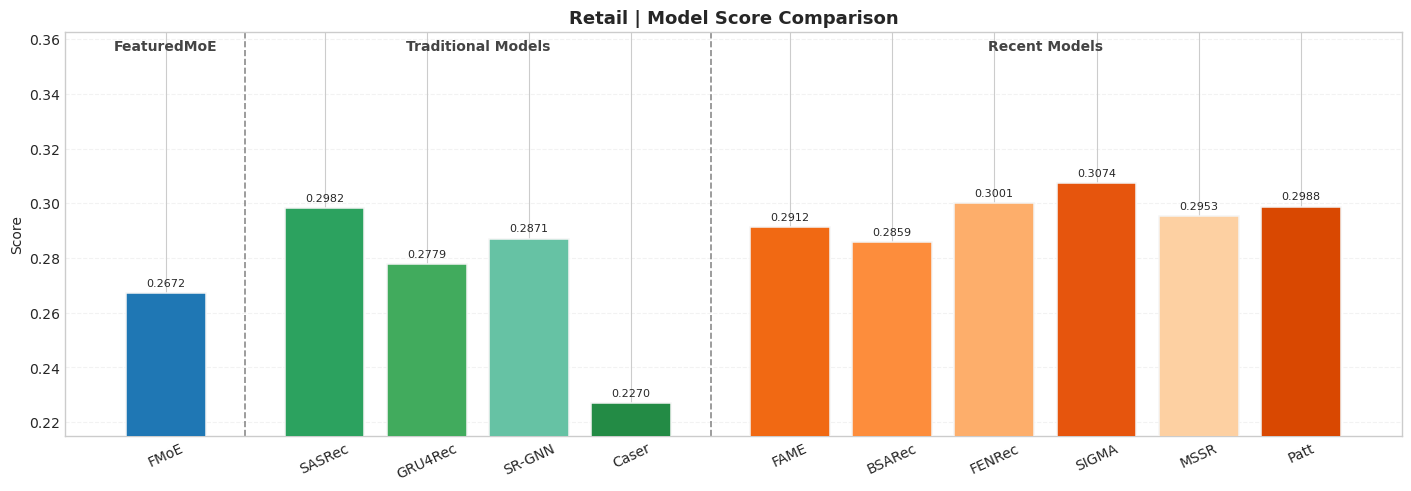

In [6]:
plot_dataset('Retail')


## KuaiRec


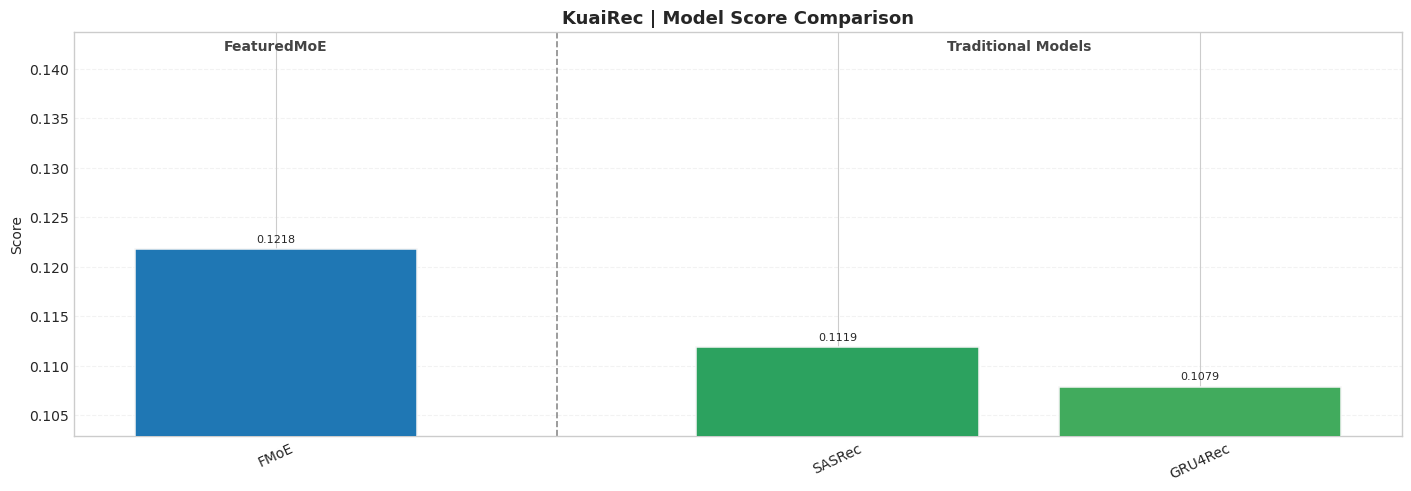

In [7]:
plot_dataset('KuaiRec')


## Last.fm


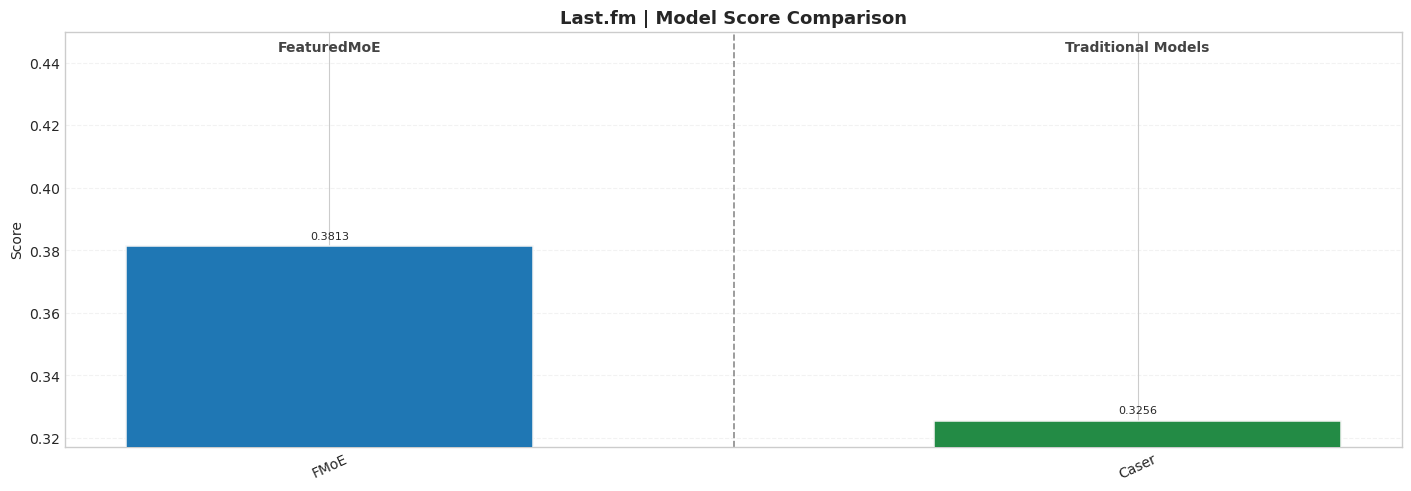

In [8]:
plot_dataset('Last.fm')


## FMoE vs SASRec Only


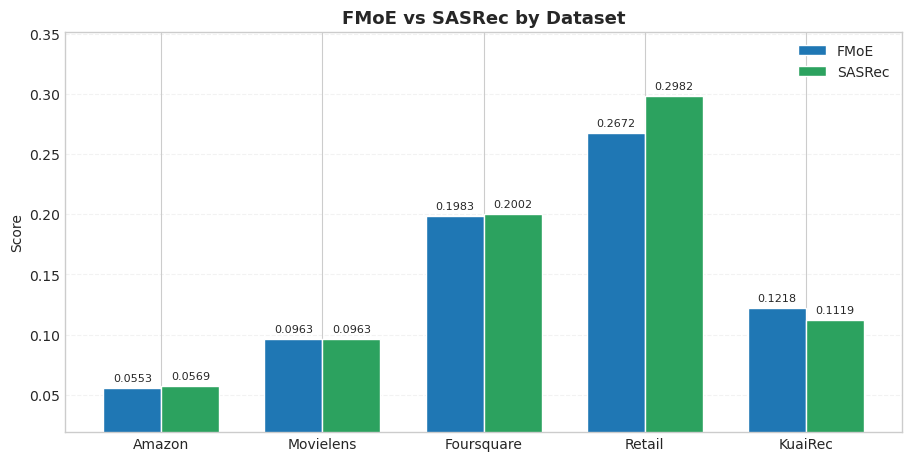

In [9]:
plot_fmoe_vs_sasrec()


## Aggregated Comparison (excluding KuaiRec / Last.fm)


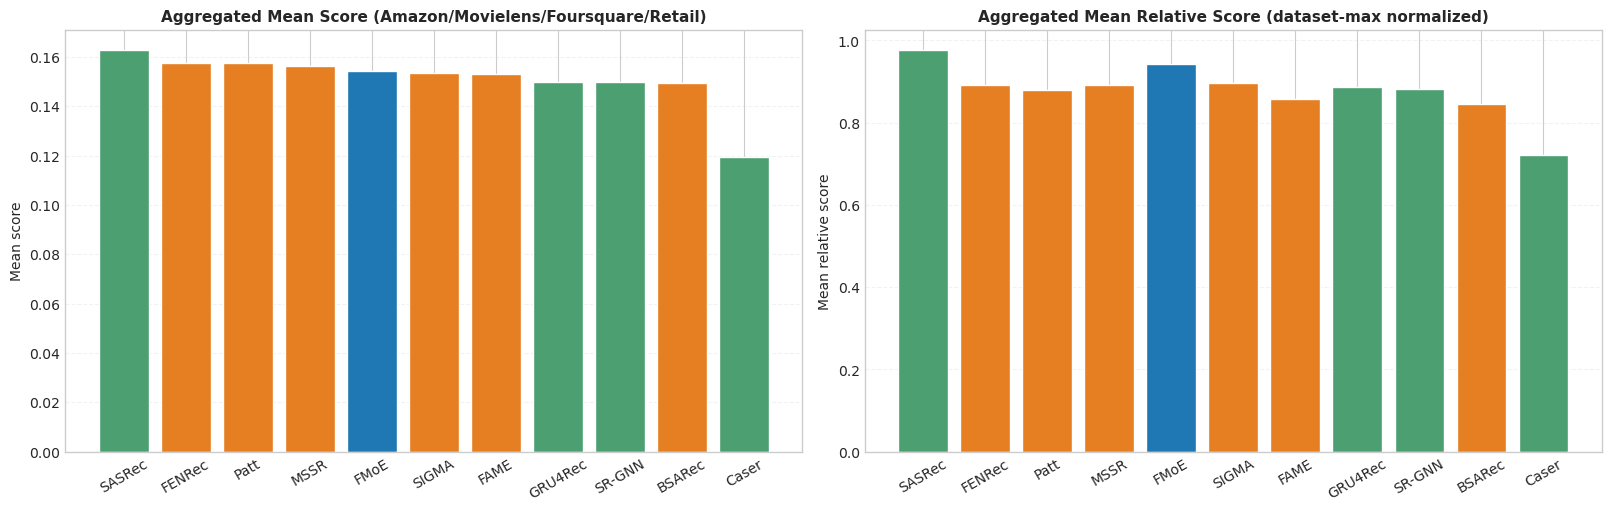

In [10]:
plot_aggregated_models_excluding_sparse()


## Layout Position Comparison (num_layers=5 fixed)

첨부 표를 수동 전사한 값으로, `VALID`와 `n_pre_layer / n_pre_macro / n_pre_mid / n_pre_micro / n_post_layer`의 관계를
"MoE가 어느 레이어 깊이에 끼워지는지" 중심으로 시각화합니다.

해석 규칙:
- `num_layers=5` 고정
- `n_pre_macro`, `n_pre_mid`, `n_pre_micro`는 `-1`이면 해당 MoE 미사용
- 값이 `0/1/2/...`이면 pre-depth 축에서의 상대 위치로 간주


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

layout_img_df = pd.DataFrame([
    {'name': 'run1',  'valid': 0.0957, 'n_pre_layer': 2, 'n_pre_macro': 1,  'n_pre_mid': 2,  'n_pre_micro': -1, 'n_post_layer': 0},
    {'name': 'run2',  'valid': 0.0956, 'n_pre_layer': 2, 'n_pre_macro': 1,  'n_pre_mid': 2,  'n_pre_micro': 0,  'n_post_layer': 0},
    {'name': 'run3',  'valid': 0.0952, 'n_pre_layer': 2, 'n_pre_macro': 1,  'n_pre_mid': -1, 'n_pre_micro': 2,  'n_post_layer': 0},
    {'name': 'run4',  'valid': 0.0952, 'n_pre_layer': 5, 'n_pre_macro': 0,  'n_pre_mid': 0,  'n_pre_micro': 0,  'n_post_layer': 0},
    {'name': 'run5',  'valid': 0.0951, 'n_pre_layer': 2, 'n_pre_macro': 1,  'n_pre_mid': 1,  'n_pre_micro': 1,  'n_post_layer': 0},
    {'name': 'run6',  'valid': 0.0950, 'n_pre_layer': 2, 'n_pre_macro': 0,  'n_pre_mid': 1,  'n_pre_micro': 1,  'n_post_layer': 1},
    {'name': 'run7',  'valid': 0.0946, 'n_pre_layer': 3, 'n_pre_macro': 1,  'n_pre_mid': -1, 'n_pre_micro': -1, 'n_post_layer': 1},
    {'name': 'run8',  'valid': 0.0923, 'n_pre_layer': 3, 'n_pre_macro': 2,  'n_pre_mid': -1, 'n_pre_micro': -1, 'n_post_layer': 0},
    {'name': 'run9',  'valid': 0.0700, 'n_pre_layer': 2, 'n_pre_macro': -1, 'n_pre_mid': 1,  'n_pre_micro': 2,  'n_post_layer': 0},
    {'name': 'run10', 'valid': 0.0603, 'n_pre_layer': 5, 'n_pre_macro': -1, 'n_pre_mid': -1, 'n_pre_micro': -1, 'n_post_layer': 0},
])

layout_img_df['num_layers'] = 5
layout_img_df = layout_img_df.sort_values('valid', ascending=False).reset_index(drop=True)
layout_img_df['rank'] = np.arange(1, len(layout_img_df) + 1)

for col in ['n_pre_macro', 'n_pre_mid', 'n_pre_micro']:
    layout_img_df[col + '_pos'] = layout_img_df[col].replace(-1, np.nan)

layout_img_df


,name,valid,n_pre_layer,n_pre_macro,n_pre_mid,n_pre_micro,n_post_layer,num_layers,rank,n_pre_macro_pos,n_pre_mid_pos,n_pre_micro_pos
0,run1,0.0957,2,1,2,-1,0,5,1,1.0,2.0,NaN
1,run2,0.0956,2,1,2,0,0,5,2,1.0,2.0,0.0
2,run3,0.0952,2,1,-1,2,0,5,3,1.0,NaN,2.0
3,run4,0.0952,5,0,0,0,0,5,4,0.0,0.0,0.0
4,run5,0.0951,2,1,1,1,0,5,5,1.0,1.0,1.0
5,run6,0.0950,2,0,1,1,1,5,6,0.0,1.0,1.0
6,run7,0.0946,3,1,-1,-1,1,5,7,1.0,NaN,NaN
7,run8,0.0923,3,2,-1,-1,0,5,8,2.0,NaN,NaN
8,run9,0.0700,2,-1,1,2,0,5,9,NaN,1.0,2.0
9,run10,0.0603,5,-1,-1,-1,0,5,10,NaN,NaN,NaN


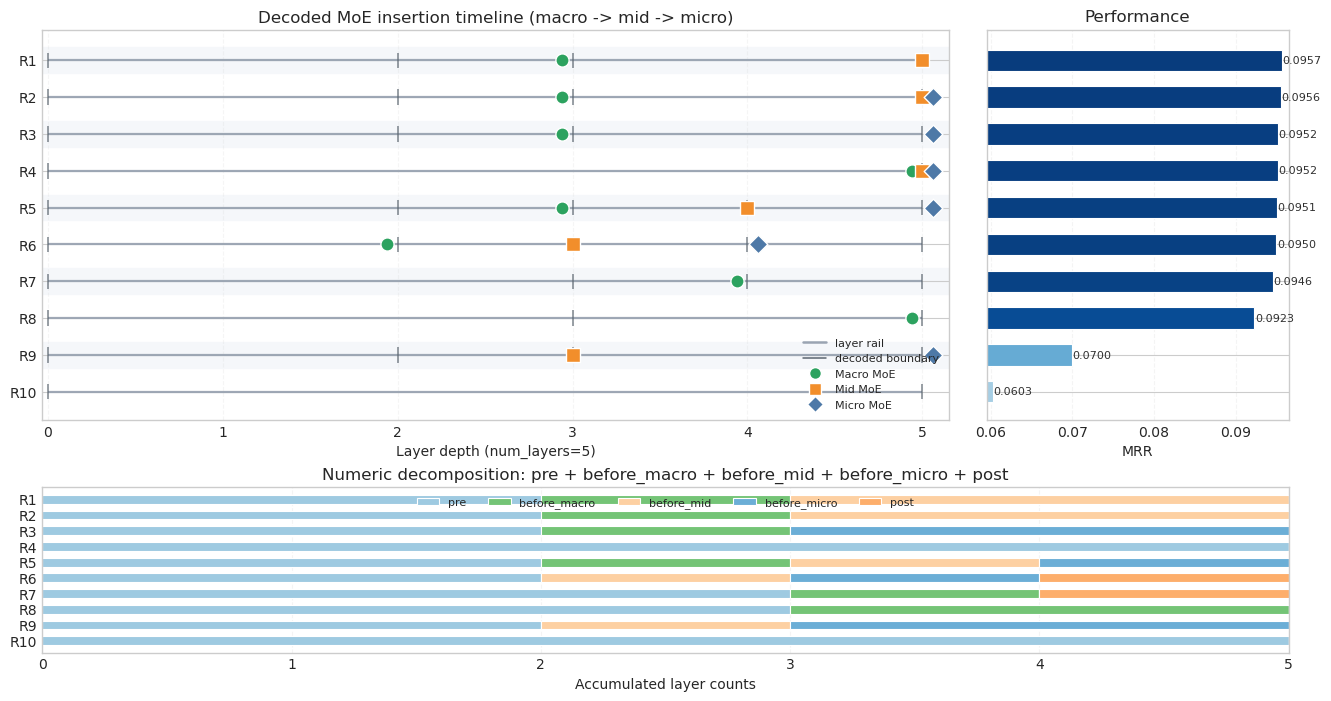

In [12]:
from matplotlib import cm, colors

# Decode by the clarified rule:
# cumulative cursor starts at pre; each key is "layers before that MoE" in fixed macro->mid->micro order.
# -1 means the MoE is removed.
def decode_positions(row):
    cur = float(row['n_pre_layer'])
    pos = {'macro': np.nan, 'mid': np.nan, 'micro': np.nan}

    if row['n_pre_macro'] >= 0:
        cur += float(row['n_pre_macro'])
        pos['macro'] = cur
    if row['n_pre_mid'] >= 0:
        cur += float(row['n_pre_mid'])
        pos['mid'] = cur
    if row['n_pre_micro'] >= 0:
        cur += float(row['n_pre_micro'])
        pos['micro'] = cur

    pos['end'] = cur + float(row['n_post_layer'])
    return pos

decoded = layout_img_df.apply(decode_positions, axis=1, result_type='expand')
plot_df = pd.concat([layout_img_df.copy(), decoded], axis=1)
plot_df = plot_df.sort_values('valid', ascending=False).reset_index(drop=True)
plot_df['rank'] = np.arange(1, len(plot_df) + 1)

fig = plt.figure(figsize=(13.2, 6.9), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[4.8, 1.6], height_ratios=[2.6, 1.1])
ax_t = fig.add_subplot(gs[0, 0])
ax_m = fig.add_subplot(gs[0, 1], sharey=ax_t)
ax_d = fig.add_subplot(gs[1, :])

# --- Top-left: timeline ---
marker_cfg = {
    'macro': ('Macro MoE', 'o', '#2ca25f', -0.06),
    'mid': ('Mid MoE', 's', '#f28e2b', 0.00),
    'micro': ('Micro MoE', 'D', '#4e79a7', +0.06),
}

for i, row in plot_df.iterrows():
    y = i
    if i % 2 == 0:
        ax_t.axhspan(y - 0.35, y + 0.35, color='#f5f7fa', zorder=0)

    ax_t.hlines(y=y, xmin=0, xmax=5, color='#9aa4b2', linewidth=1.6, alpha=0.95, zorder=1)

    cur = 0.0
    points = [cur]
    cur += float(row['n_pre_layer']); points.append(cur)
    if row['n_pre_macro'] >= 0:
        cur += float(row['n_pre_macro']); points.append(cur)
    if row['n_pre_mid'] >= 0:
        cur += float(row['n_pre_mid']); points.append(cur)
    if row['n_pre_micro'] >= 0:
        cur += float(row['n_pre_micro']); points.append(cur)
    cur += float(row['n_post_layer']); points.append(cur)

    for x in sorted(set(points)):
        ax_t.vlines(x, y - 0.21, y + 0.21, color='#5c6670', linewidth=1.1, alpha=0.8, zorder=2)

    for key, (_, marker, color, xoff) in marker_cfg.items():
        x = row[key]
        if not np.isnan(x):
            ax_t.scatter(x + xoff, y, marker=marker, s=90, color=color, edgecolor='white', linewidth=1.0, zorder=3)

ax_t.set_xlim(-0.03, 5.15)
ax_t.set_xticks(range(0, 6))
ax_t.set_xlabel('Layer depth (num_layers=5)')
ax_t.set_yticks(range(len(plot_df)))
ax_t.set_yticklabels([f'R{r}' for r in plot_df['rank']])
ax_t.invert_yaxis()
ax_t.grid(axis='x', linestyle='--', alpha=0.18)
ax_t.set_title('Decoded MoE insertion timeline (macro -> mid -> micro)')

legend_handles = [
    plt.Line2D([0], [0], color='#9aa4b2', lw=1.8, label='layer rail'),
    plt.Line2D([0], [0], color='#5c6670', lw=1.1, label='decoded boundary'),
]
for _, (label, marker, color, _) in marker_cfg.items():
    legend_handles.append(plt.Line2D([0], [0], marker=marker, color='w', label=label, markerfacecolor=color, markeredgecolor='white', markersize=8.5))
ax_t.legend(handles=legend_handles, loc='lower right', frameon=False, fontsize=8)

# --- Top-right: MRR bars ---
mrr = plot_df['valid'].values
norm = colors.Normalize(vmin=mrr.min(), vmax=mrr.max())
bar_colors = cm.Blues(0.35 + 0.6 * norm(mrr))
ax_m.barh(np.arange(len(plot_df)), mrr, color=bar_colors, edgecolor='white', linewidth=0.8, height=0.58)

ax_m.set_xlim(mrr.min() - 0.0008, mrr.max() + 0.0008)
ax_m.grid(axis='x', linestyle='--', alpha=0.2)
ax_m.set_xlabel('MRR')
ax_m.set_title('Performance')
ax_m.tick_params(axis='y', left=False, labelleft=False)
for i, v in enumerate(mrr):
    ax_m.text(v + 0.00005, i, f'{v:.4f}', va='center', fontsize=8, color='#2f2f2f')

# --- Bottom: compact decomposition ---
parts = pd.DataFrame({
    'pre': plot_df['n_pre_layer'].clip(lower=0),
    'before_macro': plot_df['n_pre_macro'].clip(lower=0),
    'before_mid': plot_df['n_pre_mid'].clip(lower=0),
    'before_micro': plot_df['n_pre_micro'].clip(lower=0),
    'post': plot_df['n_post_layer'].clip(lower=0),
})

left = np.zeros(len(parts))
part_colors = {
    'pre': '#9ecae1',
    'before_macro': '#74c476',
    'before_mid': '#fdd0a2',
    'before_micro': '#6baed6',
    'post': '#fdae6b',
}
for col in ['pre', 'before_macro', 'before_mid', 'before_micro', 'post']:
    ax_d.barh(np.arange(len(parts)), parts[col].values, left=left, height=0.56, color=part_colors[col], edgecolor='white', linewidth=0.8, label=col)
    left += parts[col].values

ax_d.set_yticks(np.arange(len(parts)))
ax_d.set_yticklabels([f'R{r}' for r in plot_df['rank']])
ax_d.invert_yaxis()
ax_d.set_xlim(0, 5)
ax_d.set_xticks(range(0, 6))
ax_d.set_xlabel('Accumulated layer counts')
ax_d.set_title('Numeric decomposition: pre + before_macro + before_mid + before_micro + post')
ax_d.grid(axis='x', linestyle='--', alpha=0.2)
ax_d.legend(frameon=False, ncol=5, fontsize=8, loc='upper center')

plt.show()



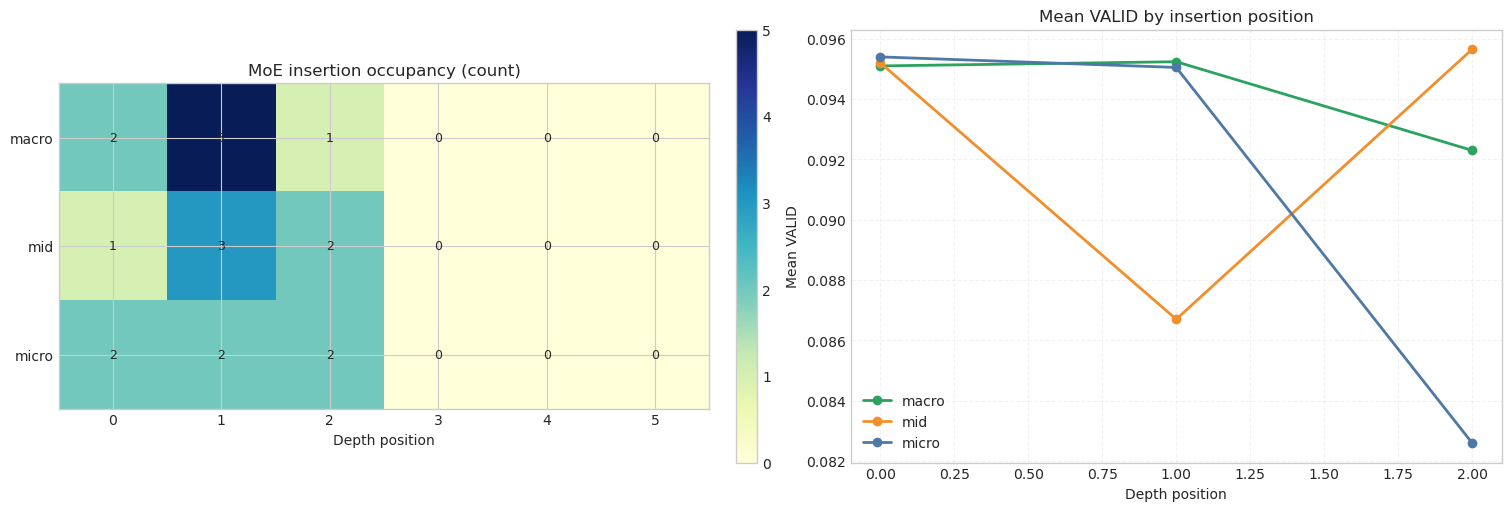

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

# Left: MoE position occupancy heatmap (counts)
position_cols = ['n_pre_macro', 'n_pre_mid', 'n_pre_micro']
position_levels = [0, 1, 2, 3, 4, 5]
occ = pd.DataFrame(0, index=['macro', 'mid', 'micro'], columns=position_levels)

for row_label, col in zip(occ.index, position_cols):
    for v in layout_img_df[col]:
        if v >= 0:
            occ.loc[row_label, int(v)] += 1

im = axes[0].imshow(occ.values, cmap='YlGnBu')
axes[0].set_xticks(range(len(position_levels)))
axes[0].set_xticklabels(position_levels)
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(['macro', 'mid', 'micro'])
axes[0].set_xlabel('Depth position')
axes[0].set_title('MoE insertion occupancy (count)')

for r in range(occ.shape[0]):
    for c in range(occ.shape[1]):
        axes[0].text(c, r, str(int(occ.values[r, c])), ha='center', va='center', fontsize=9)

fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Right: average valid by MoE insertion position
for label, col, color in [
    ('macro', 'n_pre_macro', '#2ca25f'),
    ('mid', 'n_pre_mid', '#f28e2b'),
    ('micro', 'n_pre_micro', '#4e79a7'),
]:
    tmp = layout_img_df[layout_img_df[col] >= 0].groupby(col)['valid'].mean().sort_index()
    if len(tmp) > 0:
        axes[1].plot(tmp.index, tmp.values, marker='o', linewidth=2, label=label, color=color)

axes[1].set_title('Mean VALID by insertion position')
axes[1].set_xlabel('Depth position')
axes[1].set_ylabel('Mean VALID')
axes[1].grid(True, linestyle='--', alpha=0.25)
axes[1].legend(frameon=False)

plt.show()


## Experiment Result Comparison (Custom Bar Plot)

실험별 결과를 간단한 bar plot으로 비교하는 템플릿입니다.

- 아래 `experiment_rows`만 수정하면 됩니다.
- `group`을 쓰면 baseline / experiment / ongoing 등을 색으로 구분할 수 있습니다.
- 입력 순서를 유지하므로 발표 스토리 순서대로 배치하기 좋습니다.


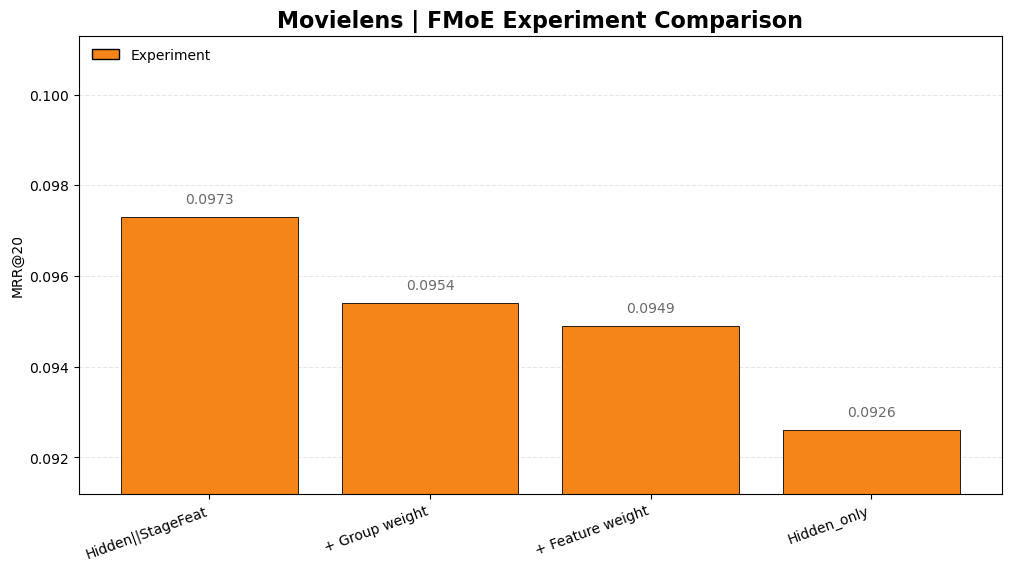

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Edit this list for each presentation / experiment sweep.
experiment_rows = [
    {'label': 'Hidden||StageFeat', 'score': 0.0973, 'group': 'Experiment'},
    {'label': '+ Group weight', 'score': 0.0954, 'group': 'Experiment'},
    {'label': '+ Feature weight', 'score': 0.0949, 'group': 'Experiment'},
    {'label': 'Hidden_only', 'score': 0.0926, 'group': 'Experiment'},
]

title = 'Movielens | FMoE Experiment Comparison'
metric_name = 'MRR@20'
sort_by_score = False  # True if you want descending bars.

group_colors = {
    'Baseline': '#4c78a8',
    'SOTA': '#5d7aa8',
    'Experiment': '#f58518',
    'Rule-based': '#54a24b',
    'Prototype': '#d2dfdd',
}

exp_df = pd.DataFrame(experiment_rows)
if sort_by_score:
    exp_df = exp_df.sort_values('score', ascending=False).reset_index(drop=True)

colors = [group_colors.get(g, '#9e9e9e') for g in exp_df['group']]
fig, ax = plt.subplots(figsize=(max(10, len(exp_df) * 1.15), 5.6), constrained_layout=True)
bars = ax.bar(exp_df['label'], exp_df['score'], color=colors, edgecolor='black', linewidth=0.6)

vmin = float(exp_df['score'].min())
vmax = float(exp_df['score'].max())
ypad = max(0.004, (vmax - vmin) * 0.25 if vmax > vmin else 0.01)
ax.set_ylim(max(0.0, vmin - ypad * 0.35), vmax + ypad)
ax.set_title(title, fontsize=16, weight='bold')
ax.set_ylabel(metric_name)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.xticks(rotation=20, ha='right')

for bar, score in zip(bars, exp_df['score']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ypad * 0.06,
        f'{score:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='dimgray',
    )

legend_items = [
    Patch(facecolor=color, edgecolor='black', label=group)
    for group, color in group_colors.items()
    if group in set(exp_df['group'])
]
if legend_items:
    ax.legend(handles=legend_items, frameon=False, loc='upper left')

plt.show()
